In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Path to dataset files: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

import cv2

In [5]:
dataset_path = os.path.join(path, "data")

print(dataset_path)

/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data


In [6]:
os.listdir(dataset_path)

['COCO-conversion-script.py',
 'labels',
 'annotations_coco.json',
 'README.md',
 'YOLO-conversion-script.py',
 'images',
 'labels-YOLO']

In [7]:
images_path = os.path.join(path, "data", "images")

os.listdir(images_path)[:5]

['vlcsnap-2025-02-19-15h10m43s692.jpg',
 'vlcsnap-2025-02-18-23h30m34s296.jpg',
 'vlcsnap-2025-02-19-14h12m25s165.jpg',
 'vlcsnap-2025-02-19-15h11m08s180.jpg',
 'vlcsnap-2025-02-18-23h15m30s977.jpg']

In [8]:
  labels_path = os.path.join(path, "data", "labels")

os.listdir(labels_path)[:5]

['vlcsnap-2025-02-19-14h18m48s452.txt',
 'vlcsnap-2025-02-19-14h21m29s062.txt',
 'vlcsnap_2025-03-16-15h14m35s770.txt',
 'vlcsnap-2025-02-18-23h25m45s670.txt',
 'vlcsnap-2025-02-19-17h09m41s152.txt']

In [9]:
sample_label = os.listdir(labels_path)[0]

with open(os.path.join(labels_path, sample_label), 'r') as f:
    print(f.read())

2 0.342187 0.558333 0.403125 0.558333 0.403125 0.591667 0.342187 0.591667
2 0.409375 0.561111 0.453125 0.561111 0.453125 0.594444 0.409375 0.594444



In [10]:
class_map = {
    0: "potholes",
    1: "cracks",
    2: "manholes"
}


In [11]:
import os

base_dir = "/content/road_classification"

classes = ["potholes", "cracks", "manholes"]

for cls in classes:
    os.makedirs(os.path.join(base_dir, cls), exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [12]:
images_path = os.path.join(path, "data", "images")
labels_path = os.path.join(path, "data", "labels")

In [13]:
import shutil

image_files = os.listdir(images_path)

for img_file in image_files:

    # Convert image filename to label filename
    label_file = img_file.replace(".jpg", ".txt")

    label_path = os.path.join(labels_path, label_file)

    # Check if label exists
    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            line = f.readline().strip()

            if line:

                # First number = class id
                class_id = int(line.split()[0])

                class_name = class_map[class_id]

                src = os.path.join(images_path, img_file)

                dst = os.path.join(base_dir, class_name, img_file)

                shutil.copy(src, dst)

print("Dataset Organized Successfully")

Dataset Organized Successfully


In [14]:
for cls in classes:
    count = len(os.listdir(os.path.join(base_dir, cls)))
    print(f"{cls}: {count} images")

potholes: 466 images
cracks: 1002 images
manholes: 541 images


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [16]:
img_size = 128
batch_size = 32

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [18]:
rescale=1./255

In [19]:
validation_split=0.2

In [20]:
rotation_range=20

In [21]:
zoom_range=0.2

In [22]:
horizontal_flip=True

In [23]:
brightness_range=[0.8,1.2]

In [24]:
train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 1608 images belonging to 3 classes.


In [25]:
val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 401 images belonging to 3 classes.


In [26]:
print(train_data.class_indices)

{'cracks': 0, 'manholes': 1, 'potholes': 2}


In [27]:
images, labels = next(train_data)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32, 3)


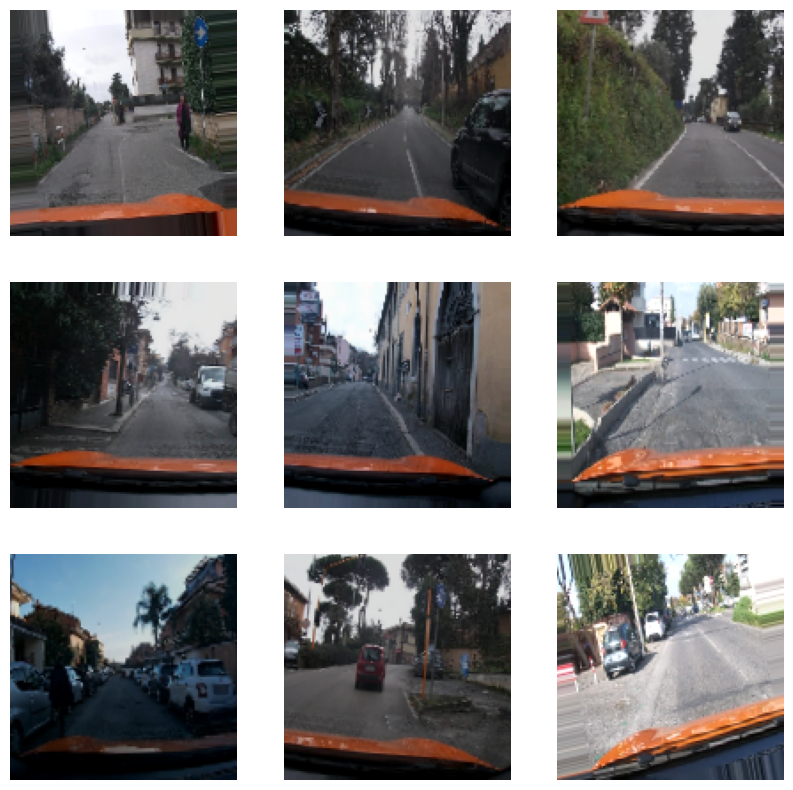

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [29]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.4820 - loss: 1.0743 - val_accuracy: 0.4988 - val_loss: 1.0479
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4988 - loss: 1.0277 - val_accuracy: 0.4988 - val_loss: 1.0452
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.4975 - loss: 1.0221 - val_accuracy: 0.4988 - val_loss: 1.0970
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.4944 - loss: 1.0185 - val_accuracy: 0.4963 - val_loss: 1.1393
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4913 - loss: 0.9982 - val_accuracy: 0.4988 - val_loss: 1.2209
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5056 - loss: 0.9845 - val_accuracy: 0.5012 - val_loss: 1.2877
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5068 - loss: 0.9910 - val_accuracy: 0.4913 - val_loss: 1.1145
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5112 - loss: 0.9822 - val_accuracy: 0.3317 - val_loss:

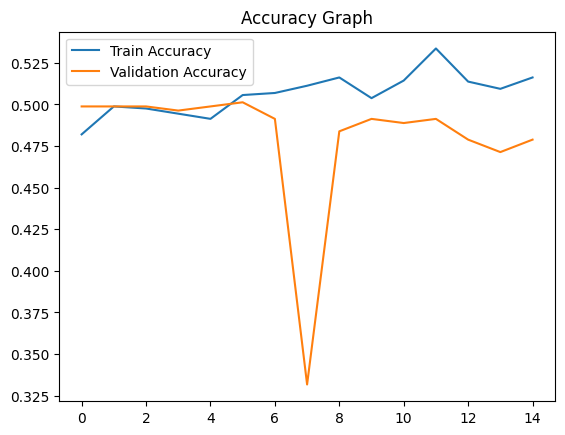

In [33]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")

plt.show()

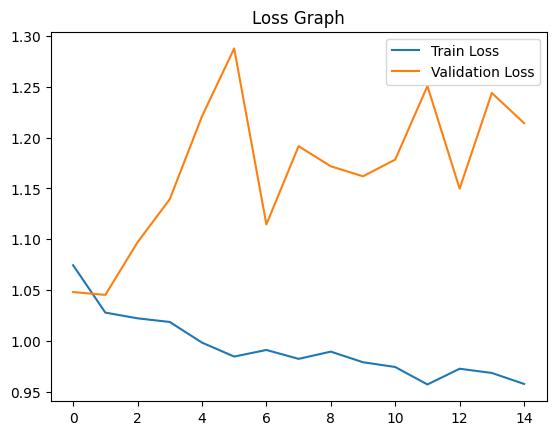

In [34]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Graph")

plt.show()

In [35]:
import numpy as np

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 507ms/step


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.97      0.67       200
           1       0.43      0.06      0.10       108
           2       0.20      0.01      0.02        93

    accuracy                           0.50       401
   macro avg       0.38      0.35      0.26       401
weighted avg       0.42      0.50      0.36       401



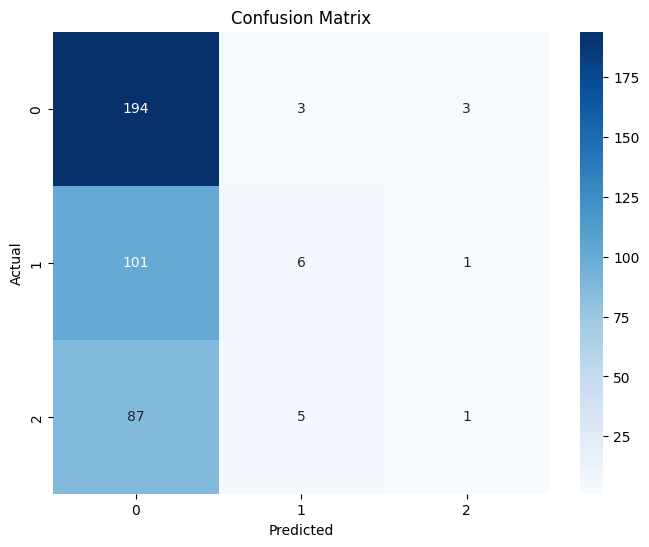

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
import numpy as np

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 599ms/step


In [41]:
class_labels = list(val_data.class_indices.keys())

print(class_labels)

['cracks', 'manholes', 'potholes']


In [42]:
import matplotlib.pyplot as plt
import cv2
import os

wrong = np.where(y_pred != y_true)[0]

print("Total Wrong Predictions:", len(wrong))

Total Wrong Predictions: 210


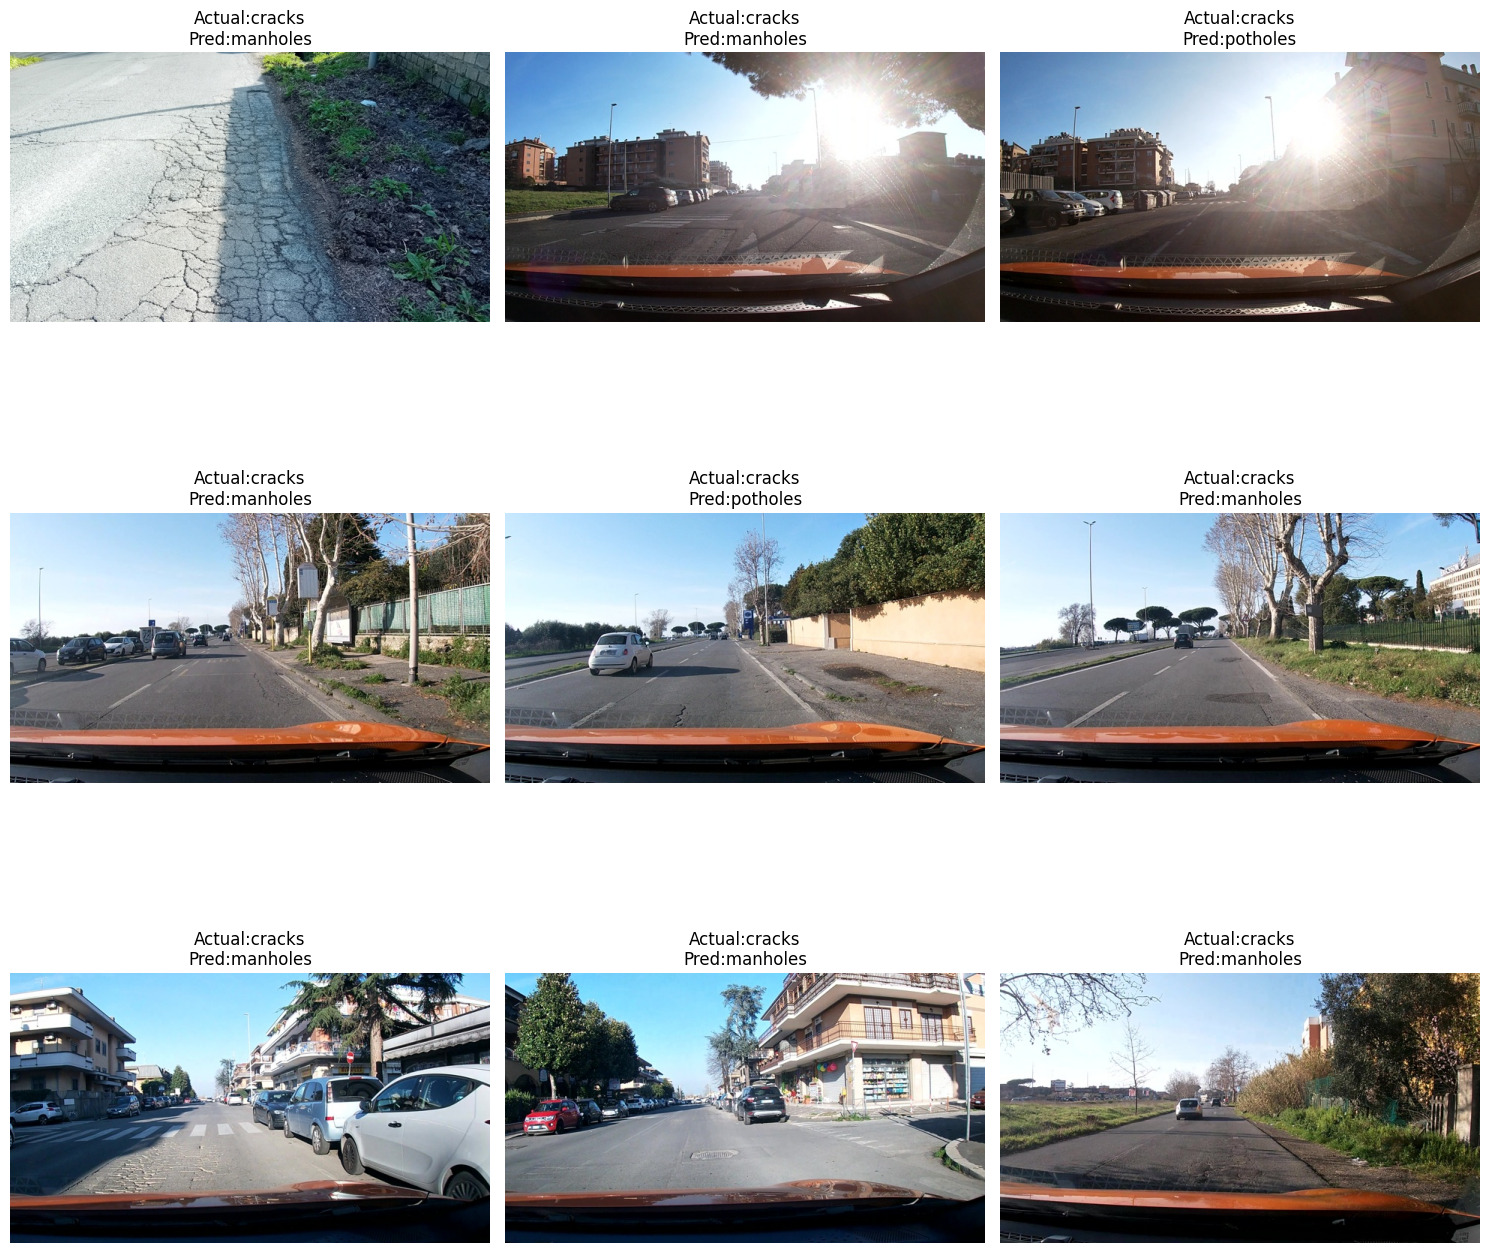

In [43]:
plt.figure(figsize=(15,15))

for i, index in enumerate(wrong[:9]):

    img_path = val_data.filepaths[index]

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    actual = class_labels[y_true[index]]

    predicted = class_labels[y_pred[index]]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f"Actual:{actual}\nPred:{predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()

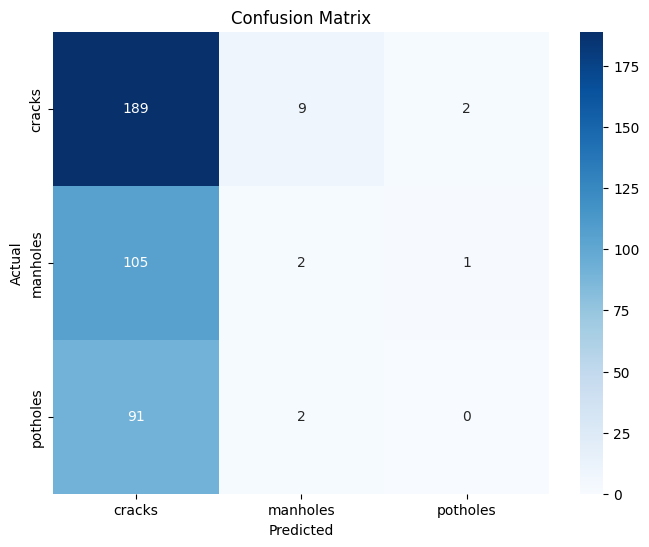

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()